# Storm Catalog Diagnostics

Generate the full set of **storm-motion diagnostic plots** from a *storm catalog*
(a folder of NetCDF storm events produced by RainyDay).

You provide the inputs and parameters through a **JSON config** (`configs/`), or
override them inline below. The exact same pipeline runs headless from the command line:

```bash
python run_diagnostics.py --config configs/testing_data.json
```

In [1]:
# Make the package importable and pick up code edits without a manual kernel restart.
import os, sys
root = os.getcwd()
while not os.path.isdir(os.path.join(root, "stormcatalog_analyzer")) and root != os.path.dirname(root):
    root = os.path.dirname(root)
os.chdir(root)
if root not in sys.path:
    sys.path.insert(0, root)
# drop any cached package modules so edits are re-read from disk on re-run
for _m in [m for m in list(sys.modules) if m.startswith("stormcatalog_analyzer")]:
    del sys.modules[_m]

from stormcatalog_analyzer.config import load_config
from stormcatalog_analyzer import pipeline
print("repo root:", root)

repo root: /Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Stormcatalog-analyzer repo


## 1. Configuration — inputs & parameters

Load a config file, then optionally override any field inline. All paths resolve
relative to `project_root` (the repo root by default).

In [2]:
cfg = load_config("configs/testing_data.json")

# --- Optional inline overrides (edit to point at YOUR catalog) ---
cfg.io.max_events = 200 # limit the number of events to process (for testing)
# cfg.io.catalog_dir               = "testing_data/StormCatalog"
# cfg.io.transposition_domain_path = "testing_data/TranspositionDomain/Domain_22.shp"
# cfg.io.output_dir                = "testing_data"
# cfg.io.domain_name               = "Test Domain"
# cfg.tracking.morph_radius_cells       = 2       # storm-merging radius (cells)
# cfg.tracking.rainfall_threshold_mmhr  = 0.5     # rainfall threshold (mm/hr)
# cfg.selection.min_duration_hr         = 6       # drop storms shorter than this (hours)
# cfg.motion.intensity_window_hr        = 12      # window for the most-intense period (hours)
# cfg.motion.n_trajectories_plotted     = 100     # number of events on the trajectory map

cfg.validate()
cfg

Config(io=IOConfig(catalog_dir='testing_data/StormCatalog', transposition_domain_path='testing_data/TranspositionDomain/Domain_22.shp', control_area_path=None, grid_path=None, output_dir='testing_data', domain_name='Test Domain', max_events=200), tracking=TrackingConfig(rainfall_var_name='rain', morph_radius_cells=2, rainfall_threshold_mmhr=0.5, ellipse_fit_method='moments', overlap_ratio_threshold=0.2, dry_spell_hr=0), selection=SelectionConfig(min_duration_hr=6, min_area_fraction=0.05), motion=MotionConfig(intensity_window_hr=12, n_trajectories_plotted=100), figure=FigureConfig(font_size=0, dpi=300, smooth_factor=0.05, arrow_scale=1.0, arrow_width=0.005, head_width=2.0, head_length=1.5), direction_grid=DirectionGridConfig(n_sectors=4, cell_size_km=50.0, count_threshold=100, start_angle_deg=None), project_root='.')

## 2. Run the pipeline

`pipeline.run` performs three stages — **track** every event, **summarize** motion (direction/speed/trajectory per storm), and **generate** outputs — saving a per-storm **CSV** (`storm_properties_<domain>.csv`) and the diagnostic figures under `output_dir/<domain_name>/`.

In [3]:

out = pipeline.run(cfg)
summary = out["summary"]
print("per-storm CSV:", out["table"])
summary.storm_properties

The longest storm has a valid duration of 20 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2003-06-23T21:00:00.000000000 to 2003-06-24T20:00:00.000000000
Selected storm duration 24 hours
ok   IOWA_Domain.nc_storm_350_20030623.nc
The longest storm has a valid duration of 24 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2016-10-16T21:00:00.000000000 to 2016-10-17T20:00:00.000000000
Selected storm duration 24 hours
ok   IOWA_Domain.nc_storm_351_20161016.nc
The longest storm has a valid duration of 22 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2011-05-08T02:00:00.000000000 to 2011-05-09T00:00:00.000000000
Selected storm duration 23 hours
ok   IOWA_Domain.nc_storm_352_20110508.nc
The longest storm has a valid duration of 19 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2015-12-13T14:00:00.000000000 to 2015-12-14T09:00:00.000000000

/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Stormcatalog-analyzer repo/stormcatalog_analyzer/plotting/diagnostics.py:199: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])
/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Stormcatalog-analyzer repo/stormcatalog_analyzer/plotting/diagnostics.py:362: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])



Saved storm-properties table:
  /Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Stormcatalog-analyzer repo/testing_data/Test Domain/storm_properties_Test Domain.csv
Saved 3 figures:
  /Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Stormcatalog-analyzer repo/testing_data/Test Domain/storm_trajectories_diagnostic_plot_Test Domain.png
  /Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Stormcatalog-analyzer repo/testing_data/Test Domain/storm_direction_vector_plot_Test Domain.png
  /Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Stormcatalog-analyzer repo/testing_data/Test Domain/storm_statistics_pairplot_Test Domain.png
per-storm CSV: /Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Stormcatalog-analyzer repo/testing_data/Test Domain/storm_properties_Test Domain.csv


,storm_event,storm_id,start_time,end_time,duration_hours,mean_speed_ms,mean_direction_deg,mean_direction_vector_deg,angular_variance,mean_intensity_mmh,peak_intensity_mmh,total_rainfall_mm,storm_area_km2,trajectory_length_km,mean_major_axis_km,mean_minor_axis_km,mean_ellipse_angle_deg
0,IOWA_Domain.nc_storm_350_20030623.nc,350,2003-06-23 21:00:00,2003-06-24 09:00:00,13,5.458821,61.300924,18.867862,0.781672,1.707085,9.812500,22.192104,35324.089551,216.169328,211.814228,94.910290,44.513988
1,IOWA_Domain.nc_storm_351_20161016.nc,351,2016-10-17 00:00:00,2016-10-17 12:00:00,13,6.360267,36.360850,52.557253,0.243821,1.993092,18.312500,25.910202,159757.547060,251.866571,381.423493,245.121362,-1.541090
2,IOWA_Domain.nc_storm_352_20110508.nc,352,2011-05-08 06:00:00,2011-05-08 18:00:00,13,6.167760,-128.657113,-114.718162,0.360528,1.485986,9.250000,19.317816,72644.515482,244.243283,390.945396,121.748728,24.408683
3,IOWA_Domain.nc_storm_353_20151213.nc,353,2015-12-13 14:00:00,2015-12-14 02:00:00,13,1.787958,24.551440,20.727075,0.634041,2.369110,8.437500,30.798429,30577.683583,70.803151,126.826304,103.502420,18.031823
4,IOWA_Domain.nc_storm_354_20021230.nc,354,2002-12-31 00:00:00,2002-12-31 12:00:00,13,4.567283,69.560277,45.598122,0.768664,2.317661,13.312500,30.129597,46709.814900,180.864416,257.375319,105.104705,-4.993806
5,IOWA_Domain.nc_storm_355_20150516.nc,355,2015-05-16 17:00:00,2015-05-17 05:00:00,13,4.165114,-72.085045,-71.632021,0.217677,1.482444,18.687500,19.271776,146729.403169,164.938529,400.482452,216.529321,1.301567
6,IOWA_Domain.nc_storm_356_20081225.nc,356,2008-12-25 11:00:00,2008-12-25 23:00:00,13,14.425526,-168.434236,-69.274614,0.917071,1.089960,11.812500,14.169482,128015.204470,571.250843,439.481252,273.153306,4.806879
7,IOWA_Domain.nc_storm_357_20140822.nc,357,2014-08-22 22:00:00,2014-08-23 08:00:00,11,9.846964,-56.717030,-52.015346,0.380383,1.801494,28.125000,19.816431,99548.672441,319.041637,386.778149,205.752537,36.484000
8,IOWA_Domain.nc_storm_358_20071019.nc,358,2007-10-19 13:00:00,2007-10-20 01:00:00,13,5.896160,28.373578,145.177310,0.885035,1.270323,12.687500,16.514193,78863.691067,233.487944,462.210209,170.735947,-13.604136
9,IOWA_Domain.nc_storm_359_20171117.nc,359,2017-11-17 09:00:00,2017-11-17 21:00:00,13,9.341464,-82.838604,-31.480209,0.762121,1.506213,12.625000,19.580765,68462.177495,369.921990,270.885227,161.377153,6.212204


In [4]:
summary.storm_properties[summary.storm_properties["angular_variance"]<0.2]   # e.g. summary.storm_properties[summary.storm_properties["storm_name"].str.contains("112")].head()

,storm_event,storm_id,start_time,end_time,duration_hours,mean_speed_ms,mean_direction_deg,mean_direction_vector_deg,angular_variance,mean_intensity_mmh,peak_intensity_mmh,total_rainfall_mm,storm_area_km2,trajectory_length_km,mean_major_axis_km,mean_minor_axis_km,mean_ellipse_angle_deg
36,IOWA_Domain.nc_storm_386_20020906.nc,386,2002-09-07 00:00:00,2002-09-07 12:00:00,13,11.048223,25.764132,21.779930,0.169791,2.383023,22.9375,30.979301,70594.830830,437.509630,288.636293,135.678176,59.950163
45,IOWA_Domain.nc_storm_395_20041208.nc,395,2004-12-08 13:00:00,2004-12-09 01:00:00,13,4.888879,-51.449679,-45.431505,0.098287,2.098164,13.5000,27.276127,170006.779348,193.599601,393.540682,265.660588,-15.986731
48,IOWA_Domain.nc_storm_398_20101024.nc,398,2010-10-24 20:00:00,2010-10-25 08:00:00,13,5.914356,-84.525373,-77.989375,0.189857,2.299768,29.9375,29.896988,242535.902604,234.208497,448.049382,355.717844,0.090202


## 3. Diagnostic figures

The full diagnostic set: storm-trajectory map + wind rose + direction/speed
distributions, the per-storm mean-direction vectors, and the storm-statistics pairplot.

storm_trajectories_diagnostic_plot_Test Domain.png


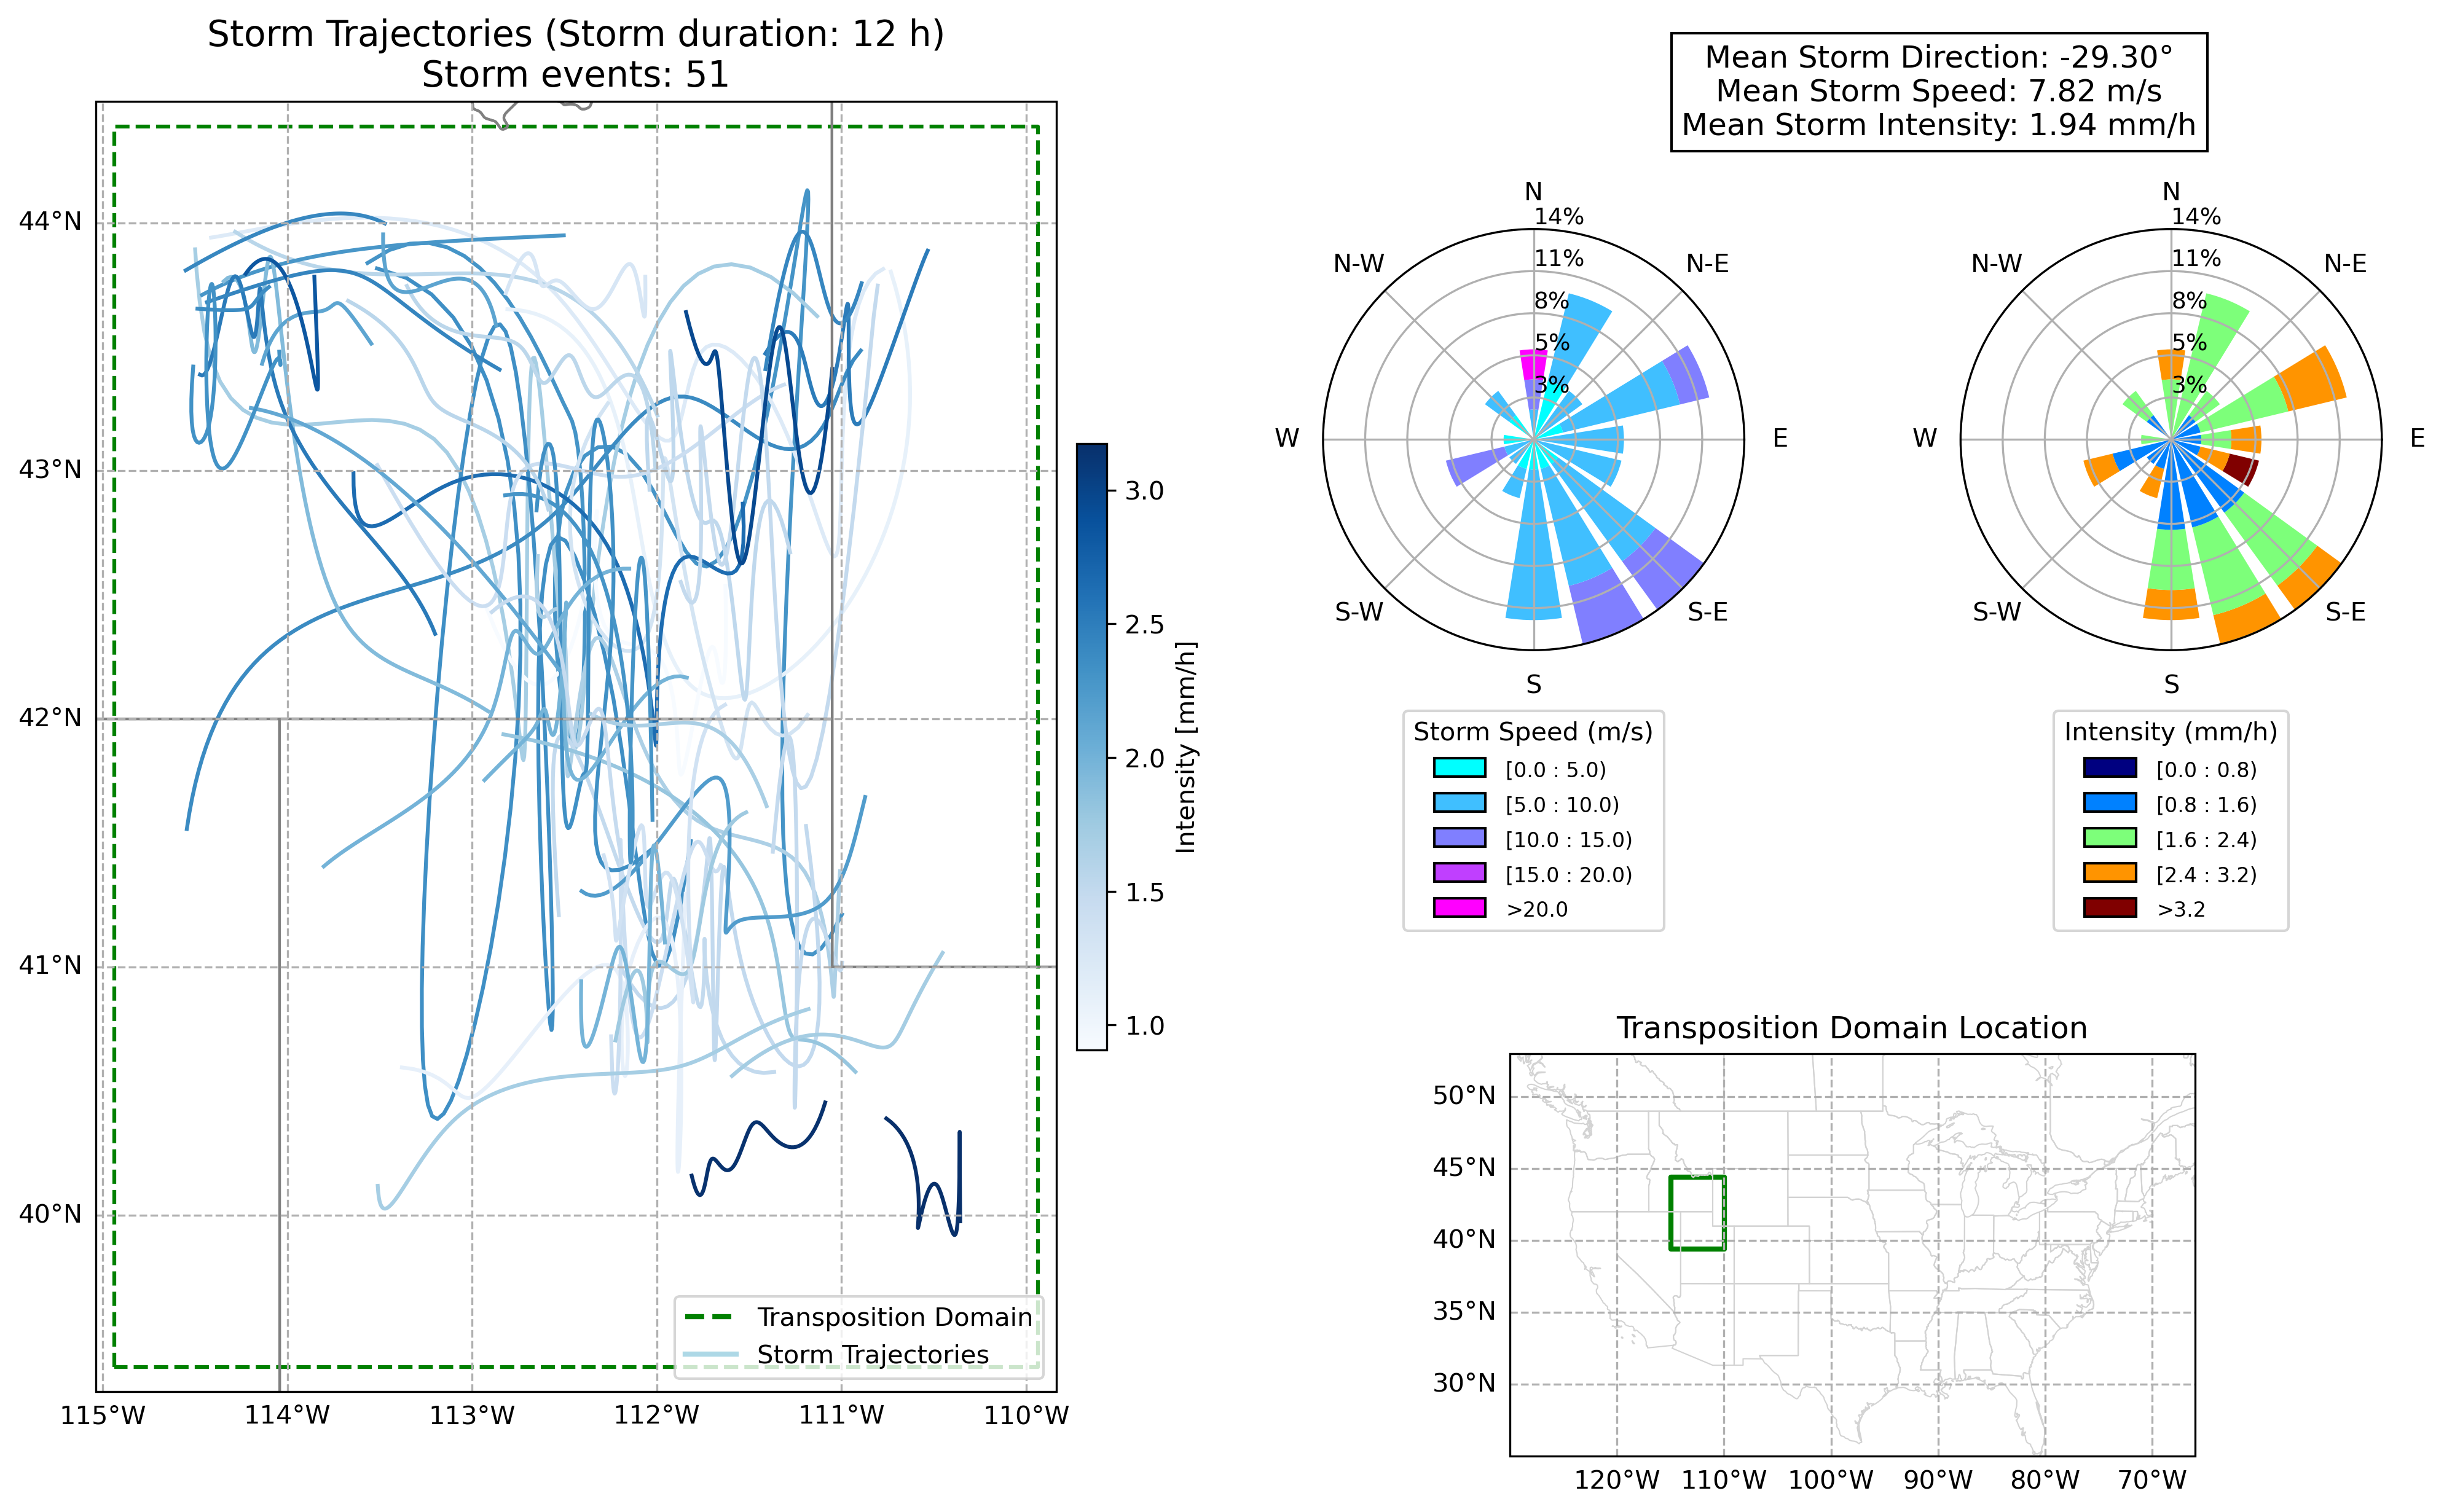

storm_direction_vector_plot_Test Domain.png


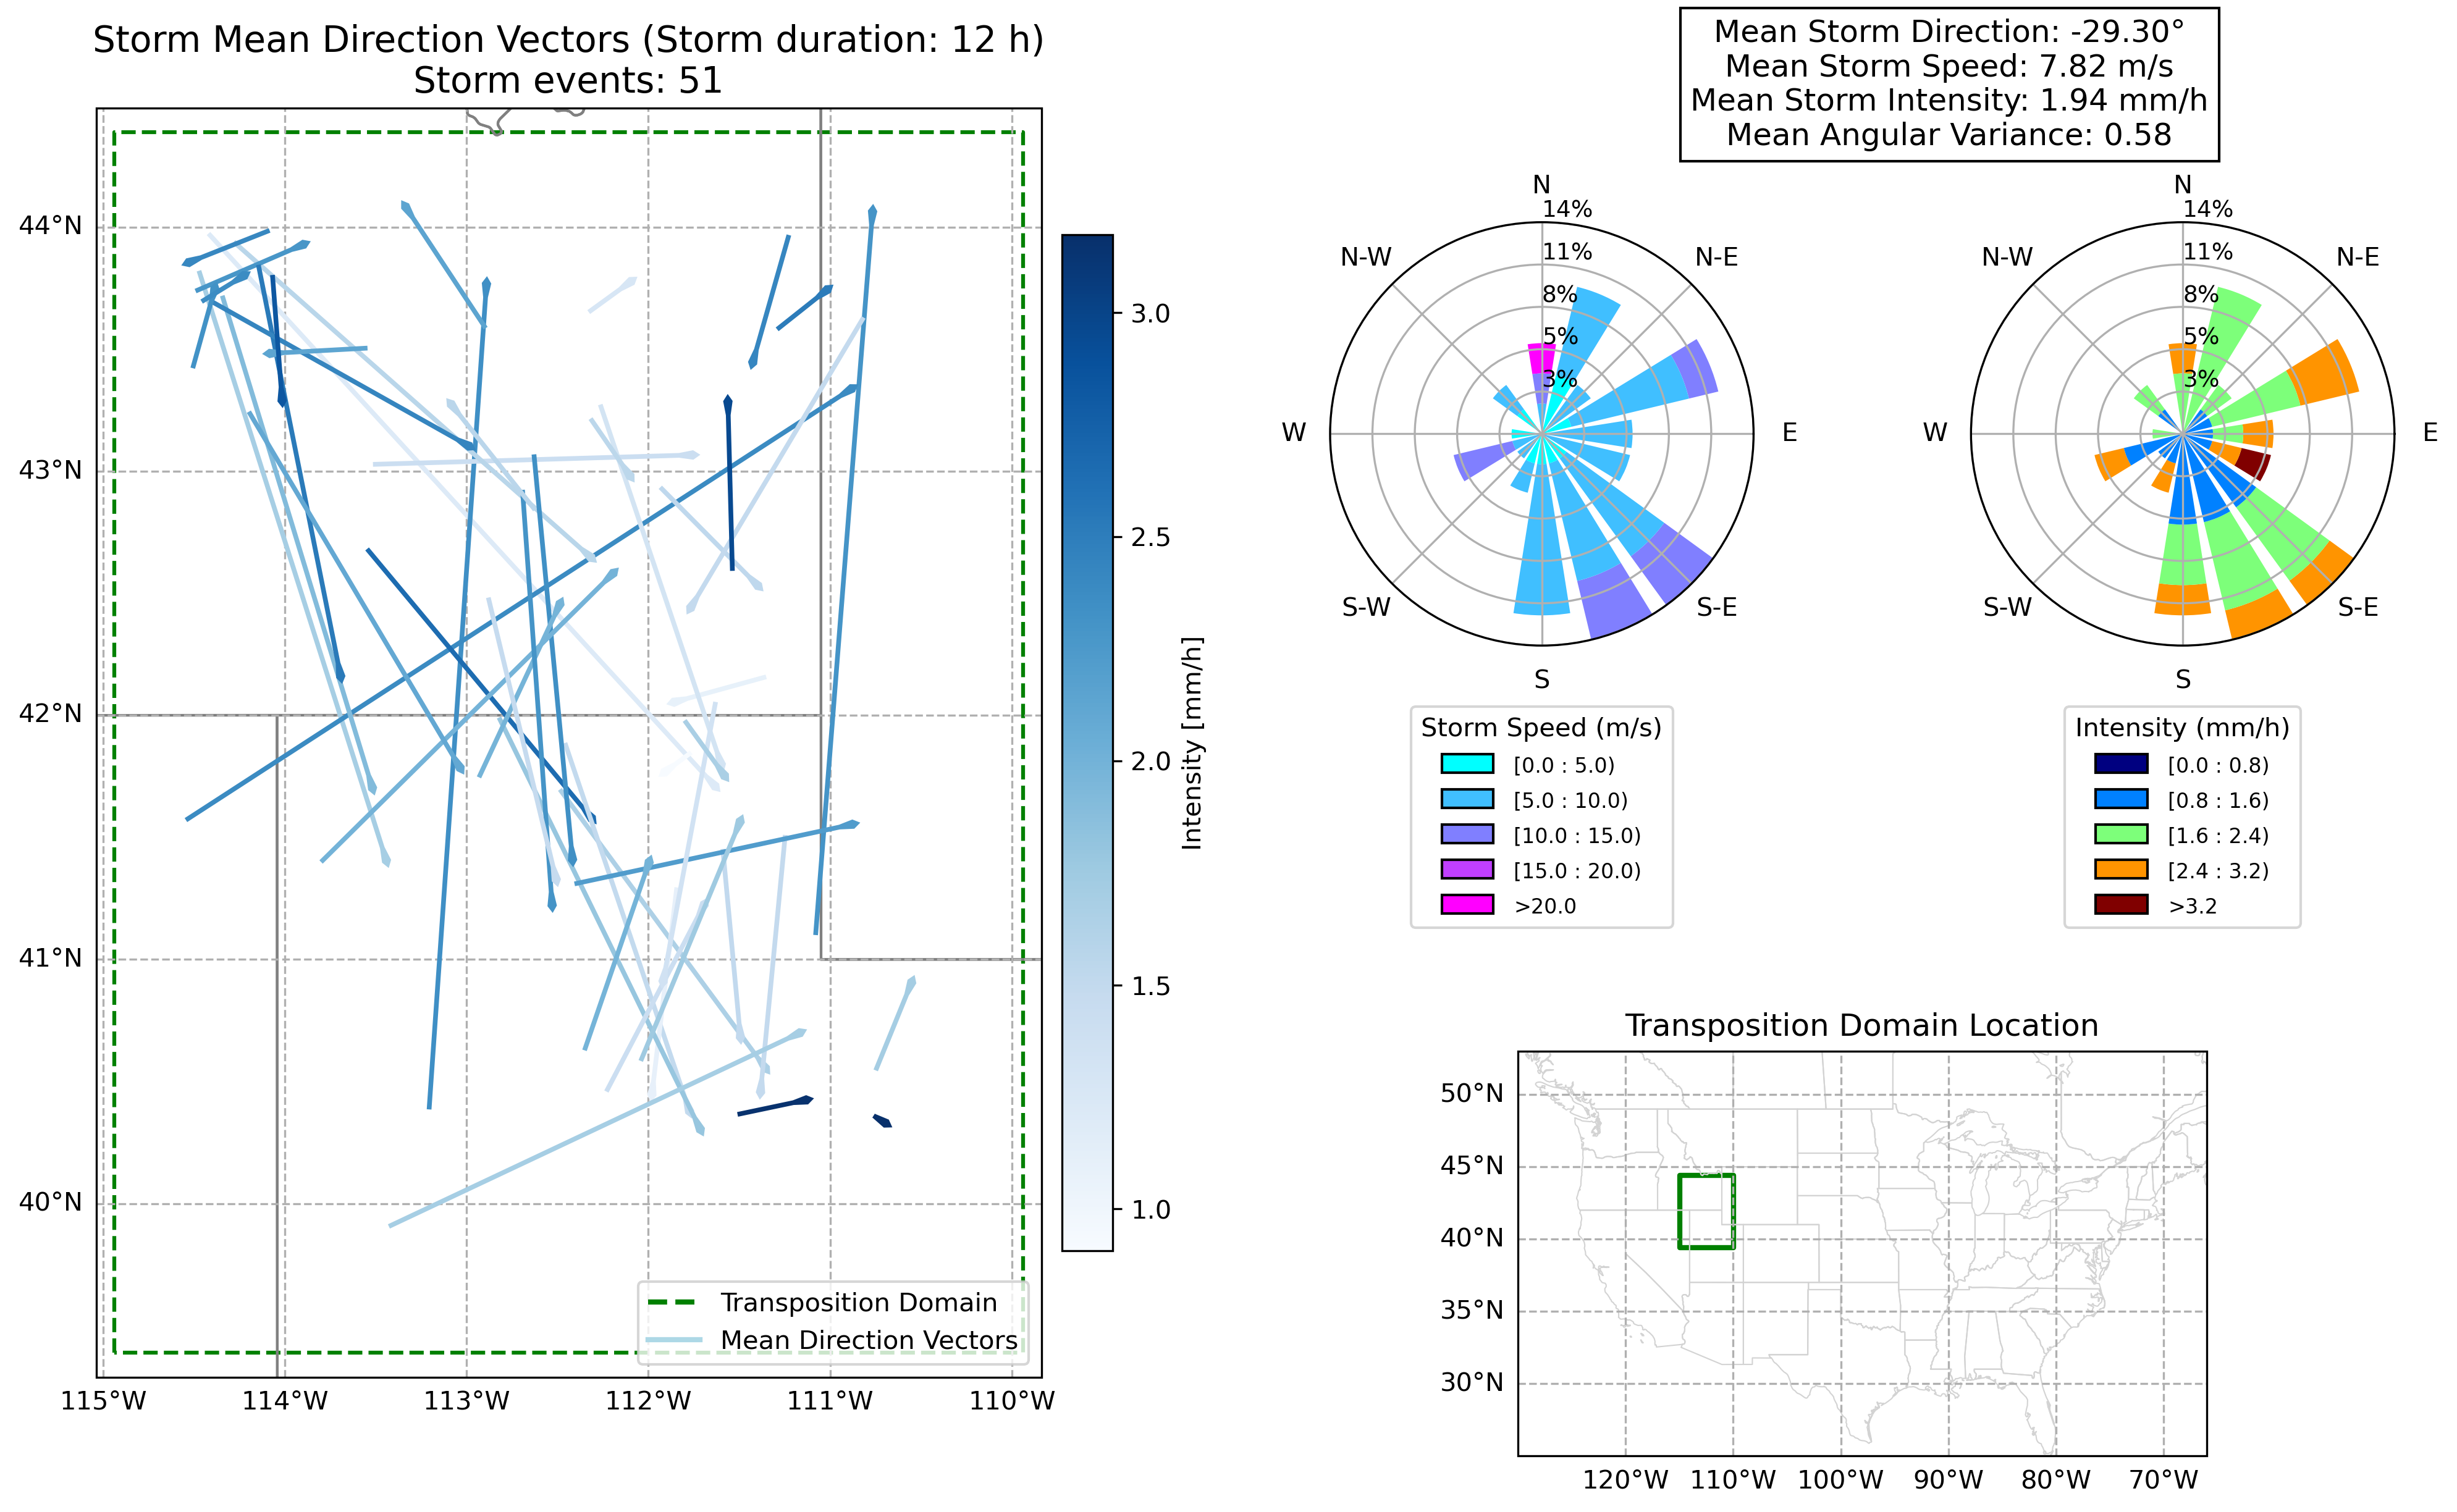

storm_statistics_pairplot_Test Domain.png


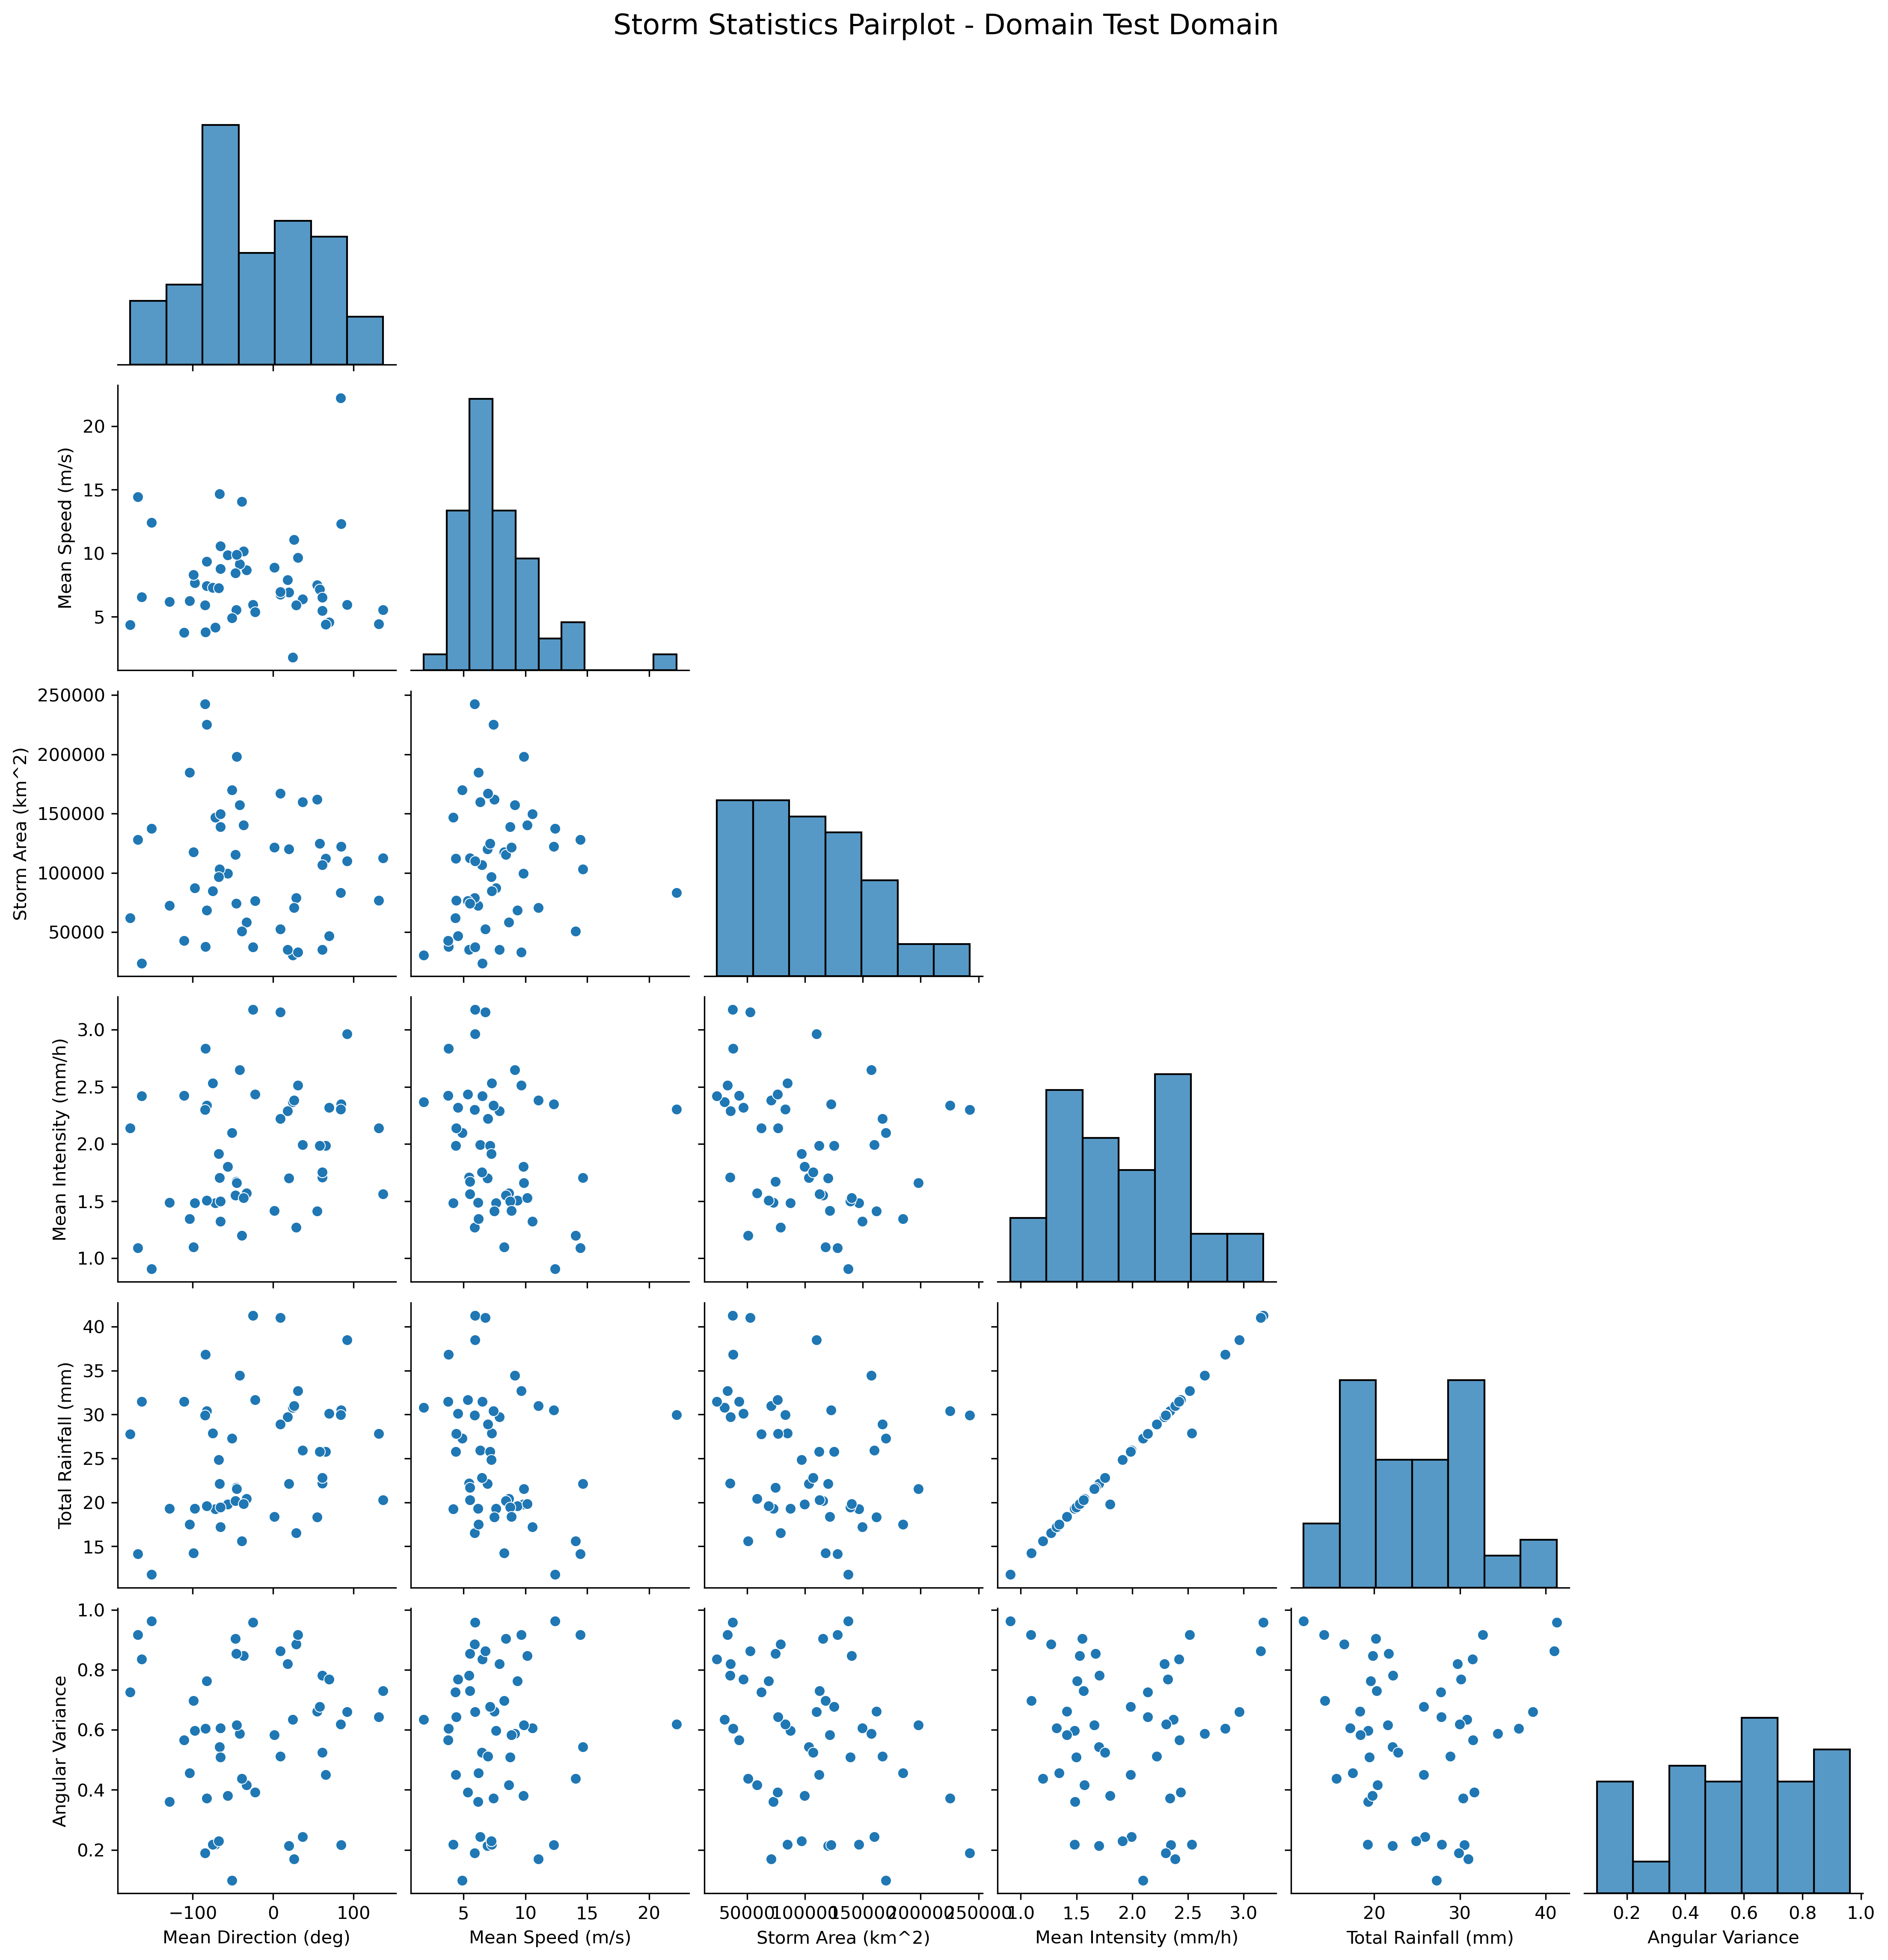

In [5]:
from IPython.display import Image, display
for fig_path in out["figures"]:
    print(fig_path.name)
    display(Image(filename=str(fig_path)))

## 4. Individual per-event figures (all storms)

Generate the storm-track + time-step panels for **every** storm in the catalog
(2 figures per storm). This reuses the tracking results from step 2 (no re-tracking),
but is still slow for large catalogs — subsample with `cfg.io.max_events` if needed.
Figures are saved under `StormTrack/` and `StormTimeSteps/`.


In [6]:
event_figs = pipeline.generate_all_event_diagnostics(cfg, out["results"], summary)
print(f"saved {len(event_figs)} per-event figures")

  per-event figures: 25/51 storms
  per-event figures: 50/51 storms
  per-event figures: 51/51 storms
Saved 102 per-event figures for 51 storms under
  /Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Stormcatalog-analyzer repo/testing_data/Test Domain/StormTrack
  /Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Stormcatalog-analyzer repo/testing_data/Test Domain/StormTimeSteps
saved 102 per-event figures


## 5. Storm-motion direction probability (grid diagnostic)

Build a storm-motion grid per storm, aggregate them into a per-cell **direction-
probability field** (four quadrants I–IV), and render the 4-panel summary:
(a) total directional counts, (b) transposition-domain location, (c) direction-
probability fields, (d) direction regions. Panel (b)'s grid index labels require the
CONUS reference grid (`cfg.io.grid_path`); they are skipped when it is not set.

Uses every retained storm — subsample with `cfg.io.max_events` for a quick look.


Built 51 storm-motion grids (20 km cells); 4 sectors (90 deg each).


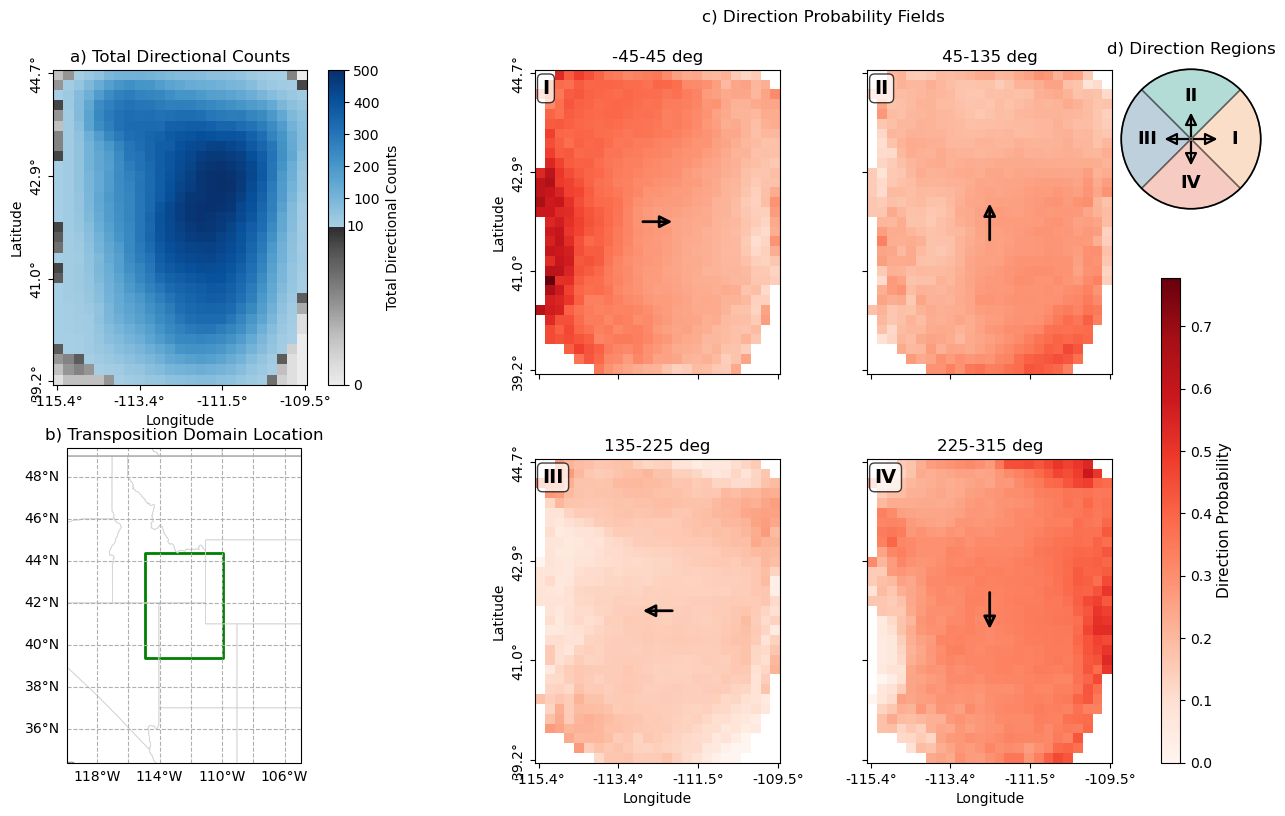

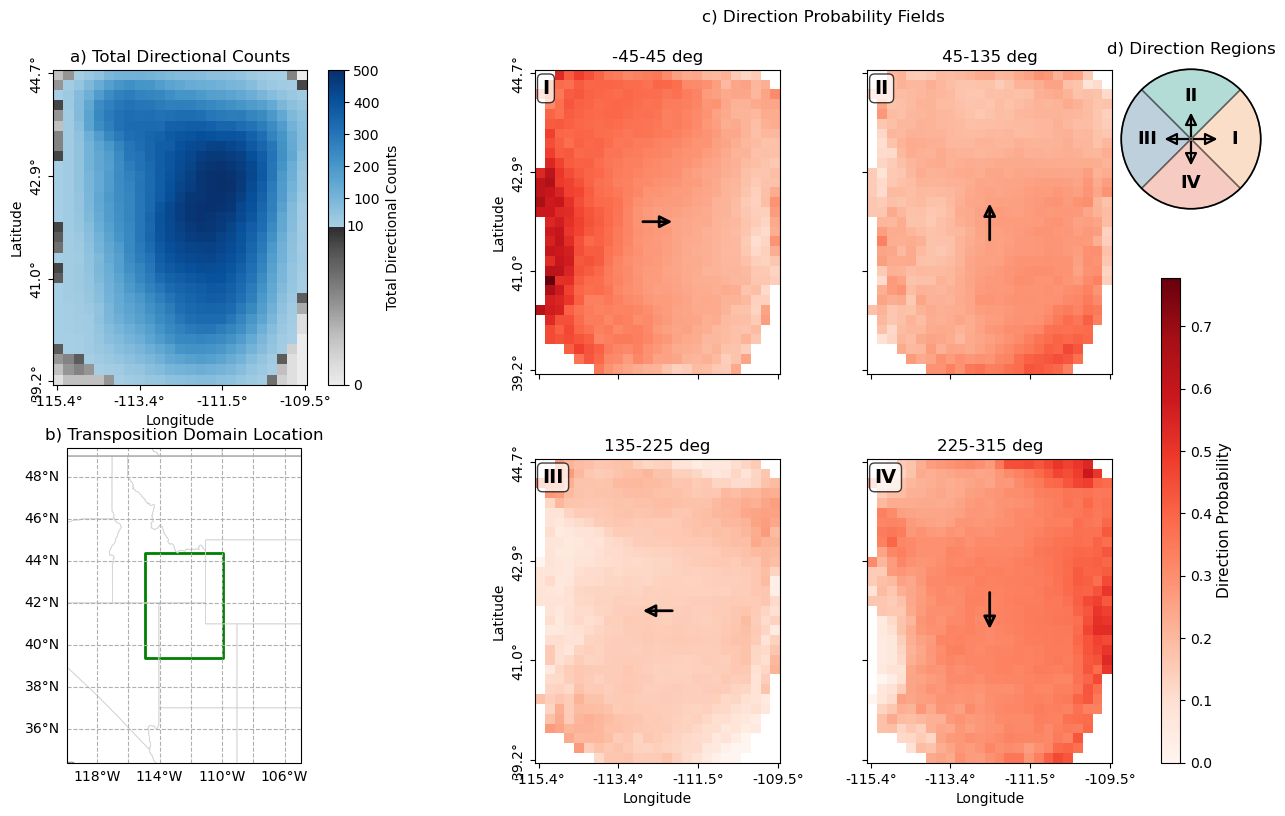

In [7]:
from stormcatalog_analyzer.plotting.motion_grid import plot_direction_probability_summary
from stormcatalog_analyzer import io as scio

# Number of sectors, grid resolution, etc. come from cfg.direction_grid
# (edit configs/testing_data.json -> "direction_grid": {"n_sectors": 8, ...})
cfg.direction_grid.n_sectors = 4
cfg.direction_grid.cell_size_km = 20
cfg.direction_grid.start_angle_deg = -45
cfg.direction_grid.count_threshold = 10
  # limit number of events to process (for testing)
prob_field = pipeline.build_direction_probability_field(out["results"], cfg)
transposition_domain = scio.load_vector(cfg.transposition_domain_path)
grid = scio.load_vector(cfg.grid_path)   # CONUS 5x5 reference grid (optional)

plot_direction_probability_summary(
    prob_field, transposition_domain, grid,
    count_threshold=cfg.direction_grid.count_threshold,
)